In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import os 
import shutil

In [103]:
def extract_labels(filename):
    # Split the filename by underscores
    parts = filename.split('_')

    # Extract labels
    drone_model = parts[0]
    maneuvering_direction = parts[1]
    fault_in_drone = parts[2]

    return drone_model, maneuvering_direction, fault_in_drone


extract_labels("C_R_PC4_mic2_892_EoeunHill_525_snr=14.638521472676231.wav")




('C', 'R', 'PC4')

In [104]:
def label_dataset(file_list):
    labels = []
    for filename in file_list:
        drone_model, maneuvering_direction, fault_in_drone = extract_labels(filename)
        # Map extracted labels to numeric values
        drone_model_label = {'A': 0, 'B': 1, 'C': 2}[drone_model]
        maneuvering_direction_label = {'R': 0, 'L': 1, 'F': 2, 'B': 3, 'CC': 4, 'C': 5}[maneuvering_direction]
        fault_in_drone_label = {'PC1': 0, 'PC2': 1, 'PC3': 2, 'PC4': 3, 'MF1': 4, 'MF2': 5, 'MF3': 6, 'MF4': 7, 'N': 8}[fault_in_drone] 
        labels.append((filename, drone_model_label, maneuvering_direction_label, fault_in_drone_label))
    return labels

# Example usage
dataset_path = '/Users/vanshnarang/Desktop/coding/ml/aries_project/training_dataset'
file_list = os.listdir(dataset_path)

labeled_training_dataset = label_dataset(file_list)



In [105]:
print(labeled_training_dataset[1])

('B_R_N_mic2_1_DuckPond_414_snr=10.18649745541961.wav', 1, 0, 8)


In [106]:
print(labeled_training_dataset[-1])

('A_B_N_mic1_552_EoeunHill_741_snr=11.32343655057069.wav', 0, 3, 8)


In [107]:
length = len(labeled_training_dataset)
print(length)

194400


In [108]:
sample_audio = '/Users/vanshnarang/Desktop/coding/ml/aries_project/training_dataset/A_B_MF1_mic1_0_ConstructionSite_527_snr=12.519732204303393.wav'
librosa_audio_data , librosa_sample_rate = librosa.load(sample_audio)

In [109]:
print(librosa_audio_data)

[0.16764902 0.22493006 0.26008663 ... 0.39735344 0.5719918  0.4131755 ]


In [110]:
print(len(librosa_audio_data))

11025


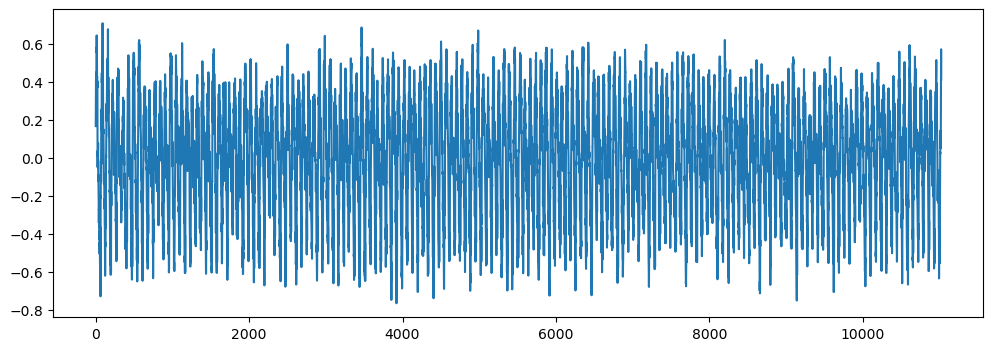

In [111]:
plt.figure(figsize=(12,4))
plt.plot(librosa_audio_data)

In [112]:
#mfccs extraction
mfccs = librosa.feature.mfcc(y=librosa_audio_data , sr=librosa_sample_rate , n_mfcc=40)
print(mfccs.shape)


(40, 22)


In [113]:
mfccs

array([[-5.06482391e+01, -3.98262558e+01, -4.63459625e+01,
        -4.27136841e+01, -4.17640457e+01, -4.16843452e+01,
        -4.40645790e+01, -4.65797577e+01, -4.84209747e+01,
        -5.19417152e+01, -5.37357330e+01, -5.03016930e+01,
        -5.18323517e+01, -5.29225426e+01, -5.14514275e+01,
        -4.89818268e+01, -4.75597153e+01, -4.68670044e+01,
        -5.06855583e+01, -5.52244606e+01, -4.70332832e+01,
        -2.28288631e+01],
       [ 1.07516556e+02,  1.12264175e+02,  1.15847145e+02,
         1.15266068e+02,  1.16667313e+02,  1.17982193e+02,
         1.11254181e+02,  1.09317841e+02,  1.13905685e+02,
         1.13293365e+02,  1.13018021e+02,  1.14997955e+02,
         1.14429459e+02,  1.16855942e+02,  1.15905701e+02,
         1.16748947e+02,  1.17371346e+02,  1.19680847e+02,
         1.19060669e+02,  1.16607803e+02,  1.19800903e+02,
         1.04946426e+02],
       [-1.46282520e+01, -3.46144028e+01, -5.37104263e+01,
        -5.83477211e+01, -5.87710114e+01, -5.72083664e+01,
    

In [240]:
def features_extractor(file_name):
    audio , sample_rate = librosa.load(file_name)
    mfccs_features = librosa.feature.mfcc(y=audio , sr=sample_rate , n_mfcc=100)
    mfccs_scaled_features = np.mean(mfccs_features.T , axis=0)

    return mfccs_scaled_features

In [241]:
extracted_training_features=[] 
training_dataset = '/Users/vanshnarang/Desktop/coding/ml/aries_project/training_dataset'
for items in labeled_training_dataset:
    file_name = os.path.join(training_dataset,items[0])
    data = features_extractor(file_name)
    extracted_training_features.append([data , items[1] ,items[2], items[3]])

In [242]:
extracted_training_features_df = pd.DataFrame(extracted_training_features,columns=['features','drone_model','maneuvering_dirn','mechanical_fault'])
extracted_training_features_df

,features,drone_model,maneuvering_dirn,mechanical_fault
0,"[-92.39258, 96.04038, -38.834797, 77.704544, -...",2,4,4
1,"[-62.444126, 111.76163, -30.521881, 73.512375,...",1,0,8
2,"[-77.263824, 120.55818, -46.3355, 77.46559, -5...",0,3,7
3,"[-75.42016, 133.30234, -33.825264, 64.14605, -...",1,1,5
4,"[-91.95676, 121.15699, -46.164974, 82.83871, -...",0,2,2
...,...,...,...,...
194395,"[-68.55669, 116.74287, -31.610441, 60.520798, ...",1,2,7
194396,"[-69.18009, 125.4374, -31.831139, 69.759674, -...",1,5,5
194397,"[-71.74996, 109.395294, -31.566572, 64.99507, ...",1,4,8
194398,"[-84.00308, 110.68318, -36.07154, 53.752968, -...",1,5,5


In [243]:
import tensorflow as tf

In [244]:
validation_dataset_path = '/Users/vanshnarang/Desktop/coding/ml/aries_project/validation_dataset'
file_list = os.listdir(validation_dataset_path)

labeled_validation_dataset = label_dataset(file_list)

In [245]:
for item in labeled_validation_dataset:
    print(item)

('C_CC_MF4_791_ConstructionSite_332_snr=13.872313893814013.wav', 2, 4, 7)
('A_R_N_680_DuckPond_113_snr=10.828884305605072.wav', 0, 0, 8)
('C_R_MF2_707_ConstructionSite_95_snr=13.331416271959686.wav', 2, 0, 5)
('C_F_MF4_766_ConstructionSite_227_snr=11.474183038058342.wav', 2, 2, 7)
('C_C_MF1_629_WestDoor_334_snr=13.307445869163024.wav', 2, 5, 4)
('C_C_MF3_773_ConstructionSite_388_snr=11.49351829353823.wav', 2, 5, 6)
('B_F_MF4_675_ConstructionSite_112_snr=11.222064034413537.wav', 1, 2, 7)
('A_B_MF3_763_SportsComplex_477_snr=12.20077271444136.wav', 0, 3, 6)
('A_R_PC4_689_SportsComplex_910_snr=14.20587065557459.wav', 0, 0, 3)
('A_B_N_6_DuckPond_649_snr=14.215112618407577.wav', 0, 3, 8)
('C_R_MF1_731_ConstructionSite_97_snr=13.348561293190208.wav', 2, 0, 4)
('C_C_PC1_692_WestDoor_105_snr=10.075505181363356.wav', 2, 5, 0)
('A_L_MF1_70_EoeunHill_444_snr=14.001064807451542.wav', 0, 1, 4)
('A_F_MF2_705_ConstructionSite_907_snr=12.222278402779672.wav', 0, 2, 5)
('B_R_PC1_804_DuckPond_257_snr=12.

In [246]:
extracted_validation_features=[] 
validation_dataset = '/Users/vanshnarang/Desktop/coding/ml/aries_project/validation_dataset'
for items in labeled_validation_dataset:
    file_name = os.path.join(validation_dataset,items[0])
    data = features_extractor(file_name)
    extracted_validation_features.append([data , items[1] ,items[2], items[3]])

/var/folders/58/w8m2q3zd7hz4w2n11g91ntg00000gn/T/ipykernel_81916/3912124753.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  audio , sample_rate = librosa.load(file_name)
/Users/vanshnarang/opt/miniconda3/envs/aries_env/lib/python3.11/site-packages/librosa/core/audio.py:183: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [247]:
print(len(extracted_validation_features))

33378


In [248]:
extracted_validation_features_df = pd.DataFrame(extracted_validation_features,columns=['features','drone_model','maneuvering_dirn','mechanical_fault'])
extracted_validation_features_df

,features,drone_model,maneuvering_dirn,mechanical_fault
0,"[-97.256004, 116.26567, -41.171753, 73.62485, ...",2,4,7
1,"[-85.54296, 107.784454, -28.366161, 80.21195, ...",0,0,8
2,"[-122.75073, 104.25809, -32.13857, 74.23496, -...",2,0,5
3,"[-91.78808, 117.176346, -41.89879, 69.47039, -...",2,2,7
4,"[-101.356224, 116.09639, -36.607243, 79.59973,...",2,5,4
...,...,...,...,...
33373,"[-135.78944, 119.62444, -27.046589, 80.518936,...",2,1,6
33374,"[-109.25174, 107.46145, -43.0483, 82.72765, -4...",2,2,7
33375,"[-75.0774, 123.409004, -33.928238, 69.29974, -...",1,3,2
33376,"[-121.935936, 124.585915, -30.507008, 66.98788...",1,5,3


In [249]:
extracted_training_features_df

,features,drone_model,maneuvering_dirn,mechanical_fault
0,"[-92.39258, 96.04038, -38.834797, 77.704544, -...",2,4,4
1,"[-62.444126, 111.76163, -30.521881, 73.512375,...",1,0,8
2,"[-77.263824, 120.55818, -46.3355, 77.46559, -5...",0,3,7
3,"[-75.42016, 133.30234, -33.825264, 64.14605, -...",1,1,5
4,"[-91.95676, 121.15699, -46.164974, 82.83871, -...",0,2,2
...,...,...,...,...
194395,"[-68.55669, 116.74287, -31.610441, 60.520798, ...",1,2,7
194396,"[-69.18009, 125.4374, -31.831139, 69.759674, -...",1,5,5
194397,"[-71.74996, 109.395294, -31.566572, 64.99507, ...",1,4,8
194398,"[-84.00308, 110.68318, -36.07154, 53.752968, -...",1,5,5


In [250]:
extracted_training_features_df.shape

(194400, 4)

In [251]:
x_train = np.array(extracted_training_features_df['features'].tolist())                 

In [252]:
x_train

array([[-9.23925781e+01,  9.60403824e+01, -3.88347969e+01, ...,
        -2.48517442e+00, -3.86869812e+00, -8.72781754e-01],
       [-6.24441261e+01,  1.11761627e+02, -3.05218811e+01, ...,
        -1.13012350e+00, -1.61822510e+00, -3.64732194e+00],
       [-7.72638245e+01,  1.20558182e+02, -4.63354988e+01, ...,
         9.02914584e-01, -2.96096444e+00, -5.92867899e+00],
       ...,
       [-7.17499619e+01,  1.09395294e+02, -3.15665722e+01, ...,
         9.31518525e-02,  1.94657743e+00,  3.52251023e-01],
       [-8.40030823e+01,  1.10683182e+02, -3.60715408e+01, ...,
         1.31961733e-01,  3.02168280e-01, -6.06833041e-01],
       [-6.68630142e+01,  1.08902740e+02, -2.79273682e+01, ...,
         6.39892042e-01,  1.60514605e+00, -1.06141675e+00]], dtype=float32)

In [253]:
x_train.shape


(194400, 100)

In [254]:
y_train_drone = np.array(extracted_training_features_df['drone_model'].tolist()) 

In [255]:
y_train_drone

array([2, 1, 0, ..., 1, 1, 0])

In [256]:
y_train_drone.shape

(194400,)

In [257]:
y_train_drone  = np.array(pd.get_dummies(y_train_drone,dtype=int))

In [258]:
y_train_drone

array([[0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       ...,
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0]])

In [259]:
y_train_drone.shape

(194400, 3)

In [260]:
y_train_dirn = np.array(extracted_training_features_df['maneuvering_dirn'].tolist()) 
y_train_dirn = np.array(pd.get_dummies(y_train_dirn,dtype=int))

In [261]:
y_train_dirn

array([[0, 0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       ...,
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1],
       [0, 0, 0, 1, 0, 0]])

In [262]:
y_train_fault = np.array(extracted_training_features_df['mechanical_fault'].tolist()) 
y_train_fault = np.array(pd.get_dummies(y_train_fault,dtype=int))

In [263]:
y_train_fault

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 1, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1]])

In [264]:
y_train_fault.shape

(194400, 9)

In [265]:
y_train_dirn.shape

(194400, 6)

In [266]:
x_val = np.array(extracted_validation_features_df['features'].tolist())
y_val_drone = np.array(extracted_validation_features_df['drone_model'].tolist())
y_val_dirn = np.array(extracted_validation_features_df['maneuvering_dirn'].tolist())
y_val_fault = np.array(extracted_validation_features_df['mechanical_fault'].tolist())

In [267]:
x_val.shape

(33378, 100)

In [268]:
y_val_drone = np.array(pd.get_dummies(y_val_drone,dtype=int))
y_val_dirn = np.array(pd.get_dummies(y_val_dirn,dtype=int))
y_val_fault = np.array(pd.get_dummies(y_val_fault,dtype=int))

In [269]:
y_val_drone

array([[0, 0, 1],
       [1, 0, 0],
       [0, 0, 1],
       ...,
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1]])

In [270]:
y_val_drone.shape

(33378, 3)

In [271]:
y_val_dirn.shape

(33378, 6)

In [272]:
y_val_fault.shape

(33378, 9)

In [48]:
testing_sample = '/Users/vanshnarang/Desktop/coding/ml/aries_project/testing_dataset/A_B_MF1_0_ConstructionSite_6_snr=10.926310539796413.wav'
testing_features = features_extractor(testing_sample)

In [49]:
testing_features

array([-80.7914   , 104.4303   , -41.630314 ,  81.52336  , -63.078964 ,
        44.712215 , -35.488815 ,  20.982244 , -25.673523 ,  -1.6369001,
        -1.9161836,  -9.438031 ,   5.1032863, -17.829256 ,   7.222618 ,
       -24.311956 ,   3.091133 , -21.409824 ,  -2.4195004,  -5.2802424,
         6.1424775,  15.625376 ,  14.292517 ,  24.462494 ,   5.287813 ,
        17.531944 ,   2.193258 ,  12.080639 ,  -5.615894 ,  -3.0939186,
        -8.510154 ,  -6.8466053,  -0.633976 ,  -8.256914 ,  -3.6208336,
       -13.493332 ,   1.0824505,  -8.242422 ,  -4.7031436, -11.603152 ],
      dtype=float32)

In [50]:
testing_features.reshape((1,40))

array([[-80.7914   , 104.4303   , -41.630314 ,  81.52336  , -63.078964 ,
         44.712215 , -35.488815 ,  20.982244 , -25.673523 ,  -1.6369001,
         -1.9161836,  -9.438031 ,   5.1032863, -17.829256 ,   7.222618 ,
        -24.311956 ,   3.091133 , -21.409824 ,  -2.4195004,  -5.2802424,
          6.1424775,  15.625376 ,  14.292517 ,  24.462494 ,   5.287813 ,
         17.531944 ,   2.193258 ,  12.080639 ,  -5.615894 ,  -3.0939186,
         -8.510154 ,  -6.8466053,  -0.633976 ,  -8.256914 ,  -3.6208336,
        -13.493332 ,   1.0824505,  -8.242422 ,  -4.7031436, -11.603152 ]],
      dtype=float32)

In [51]:
testing_features.shape


(40,)

In [52]:
x_train.shape

(194400, 40)

In [53]:
x_train

array([[-9.23925781e+01,  9.60403824e+01, -3.88347969e+01, ...,
        -1.13969660e+01,  9.25004959e-01, -1.66249502e+00],
       [-6.24441261e+01,  1.11761627e+02, -3.05218811e+01, ...,
        -7.74106407e+00,  1.92450607e+00, -5.43311644e+00],
       [-7.72638245e+01,  1.20558182e+02, -4.63354988e+01, ...,
        -8.49435997e+00, -7.90149629e-01, -7.18797588e+00],
       ...,
       [-7.17499619e+01,  1.09395294e+02, -3.15665722e+01, ...,
        -3.60708070e+00,  2.43351531e+00, -6.51295424e+00],
       [-8.40030823e+01,  1.10683182e+02, -3.60715408e+01, ...,
        -8.68930149e+00,  2.47487664e+00, -4.81828880e+00],
       [-6.68630142e+01,  1.08902740e+02, -2.79273682e+01, ...,
        -5.93000507e+00, -7.87461326e-02, -7.15002871e+00]], dtype=float32)

In [54]:
testing_features

array([-80.7914   , 104.4303   , -41.630314 ,  81.52336  , -63.078964 ,
        44.712215 , -35.488815 ,  20.982244 , -25.673523 ,  -1.6369001,
        -1.9161836,  -9.438031 ,   5.1032863, -17.829256 ,   7.222618 ,
       -24.311956 ,   3.091133 , -21.409824 ,  -2.4195004,  -5.2802424,
         6.1424775,  15.625376 ,  14.292517 ,  24.462494 ,   5.287813 ,
        17.531944 ,   2.193258 ,  12.080639 ,  -5.615894 ,  -3.0939186,
        -8.510154 ,  -6.8466053,  -0.633976 ,  -8.256914 ,  -3.6208336,
       -13.493332 ,   1.0824505,  -8.242422 ,  -4.7031436, -11.603152 ],
      dtype=float32)

In [55]:
testing_features.reshape(1,40)

array([[-80.7914   , 104.4303   , -41.630314 ,  81.52336  , -63.078964 ,
         44.712215 , -35.488815 ,  20.982244 , -25.673523 ,  -1.6369001,
         -1.9161836,  -9.438031 ,   5.1032863, -17.829256 ,   7.222618 ,
        -24.311956 ,   3.091133 , -21.409824 ,  -2.4195004,  -5.2802424,
          6.1424775,  15.625376 ,  14.292517 ,  24.462494 ,   5.287813 ,
         17.531944 ,   2.193258 ,  12.080639 ,  -5.615894 ,  -3.0939186,
         -8.510154 ,  -6.8466053,  -0.633976 ,  -8.256914 ,  -3.6208336,
        -13.493332 ,   1.0824505,  -8.242422 ,  -4.7031436, -11.603152 ]],
      dtype=float32)

In [57]:
testing_features = np.reshape(testing_features, (1, 40))

In [58]:
import tensorflow as tf

# Define constants
num_mfcc_features = 40  # Number of MFCC features
num_drone_classes = 3  
num_direction_classes = 6 
num_fault_classes = 9 

# Create the model

input_layer = tf.keras.layers.Input(shape=(num_mfcc_features,))
reshape_layer = tf.keras.layers.Reshape((num_mfcc_features, 1))(input_layer)  # Reshape for conv2D

# Convolutional layers
x = tf.keras.layers.Conv1D(32, 3, strides=2, padding='same', activation='relu')(reshape_layer)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(64, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(128, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

# Flatten and dense layers
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)

# Task-specific output layers
output_drone_model = tf.keras.layers.Dense(num_drone_classes, activation='softmax', name='drone_model')(x)
output_direction = tf.keras.layers.Dense(num_direction_classes, activation='softmax', name='direction')(x)
output_fault = tf.keras.layers.Dense(num_fault_classes, activation='softmax', name='fault')(x)

# Create the model
model = tf.keras.models.Model(inputs=input_layer, outputs=[output_drone_model, output_direction, output_fault])

# Compile model
model.compile(
    loss={
        'drone_model': 'categorical_crossentropy',
        'direction': 'categorical_crossentropy',
        'fault': 'categorical_crossentropy',
    },
    optimizer=tf.keras.optimizers.legacy.RMSprop(),
    metrics=['accuracy'],
)

# Print model summary
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 40)]         0           []                               
                                                                                                  
 reshape (Reshape)              (None, 40, 1)        0           ['input_1[0][0]']                
                                                                                                  
 conv1d (Conv1D)                (None, 20, 32)       128         ['reshape[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 20, 32)      128         ['conv1d[0][0]']                 
 alization)                                                                                   

In [59]:
x_train.shape


(194400, 40)

In [60]:
print(tf.__version__)


2.12.0


In [61]:
# Train the model
model.fit(x_train, [y_train_drone, y_train_dirn, y_train_fault], epochs=10, batch_size=32, validation_data=(x_val, [y_val_drone, y_val_dirn, y_val_fault]))

Epoch 1/10


2024-03-31 14:45:00.070280: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


6075/6075 [==============================] - 19s 3ms/step - loss: 2.6296 - drone_model_loss: 0.0867 - direction_loss: 1.4100 - fault_loss: 1.1330 - drone_model_accuracy: 0.9707 - direction_accuracy: 0.4492 - fault_accuracy: 0.5859 - val_loss: 2.1888 - val_drone_model_loss: 0.0209 - val_direction_loss: 1.1329 - val_fault_loss: 1.0351 - val_drone_model_accuracy: 0.9939 - val_direction_accuracy: 0.5721 - val_fault_accuracy: 0.6492
Epoch 2/10
6075/6075 [==============================] - 18s 3ms/step - loss: 1.9978 - drone_model_loss: 0.0481 - direction_loss: 1.1189 - fault_loss: 0.8308 - drone_model_accuracy: 0.9848 - direction_accuracy: 0.5767 - fault_accuracy: 0.7019 - val_loss: 1.6056 - val_drone_model_loss: 0.0180 - val_direction_loss: 0.9486 - val_fault_loss: 0.6390 - val_drone_model_accuracy: 0.9947 - val_direction_accuracy: 0.6372 - val_fault_accuracy: 0.7642
Epoch 3/10
6075/6075 [==============================] - 18s 3ms/step - loss: 1.7858 - drone_model_loss: 0.0397 - direction_lo

In [114]:
import os


folder_path = '/Users/vanshnarang/Desktop/coding/ml/aries_project/test/mic1'

# Iterate over the files in the folder
for file_name in os.listdir(folder_path):
    # Check if the item is a file
    if os.path.isfile(os.path.join(folder_path, file_name)):
        # Split the file name into base name and extension
        base_name, ext = os.path.splitext(file_name)
        
        # Append the folder name after the extension
        new_file_name = f"{base_name}{ext}_{os.path.basename(folder_path)}"
        
        # Rename the file
        os.rename(os.path.join(folder_path, file_name), os.path.join(folder_path, new_file_name))


In [115]:
import os


folder_path = '/Users/vanshnarang/Desktop/coding/ml/aries_project/test/mic2'

# Iterate over the files in the folder
for file_name in os.listdir(folder_path):
    # Check if the item is a file
    if os.path.isfile(os.path.join(folder_path, file_name)):
        # Split the file name into base name and extension
        base_name, ext = os.path.splitext(file_name)
        
        # Append the folder name after the extension
        new_file_name = f"{base_name}{ext}_{os.path.basename(folder_path)}"
        
        # Rename the file
        os.rename(os.path.join(folder_path, file_name), os.path.join(folder_path, new_file_name))

MODEL 3

In [49]:
import tensorflow as tf

# Define constants
num_mfcc_features = 40  # Number of MFCC features
num_drone_classes = 3  
num_direction_classes = 6 
num_fault_classes = 9 

# Create the model

input_layer = tf.keras.layers.Input(shape=(num_mfcc_features,))
reshape_layer = tf.keras.layers.Reshape((num_mfcc_features, 1))(input_layer)  # Reshape for conv2D

# Convolutional layers
x = tf.keras.layers.Conv1D(32, 3, strides=2, padding='same', activation='relu')(reshape_layer)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(64, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(128, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

# Flatten and dense layers
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)

# Task-specific output layers
output_drone_model = tf.keras.layers.Dense(num_drone_classes, activation='softmax', name='drone_model')(x)
output_direction = tf.keras.layers.Dense(num_direction_classes, activation='softmax', name='direction')(x)
output_fault = tf.keras.layers.Dense(num_fault_classes, activation='softmax', name='fault')(x)

# Create the model
model = tf.keras.models.Model(inputs=input_layer, outputs=[output_drone_model, output_direction, output_fault])

# Compile model
model.compile(
    loss={
        'drone_model': 'categorical_crossentropy',
        'direction': 'categorical_crossentropy',
        'fault': 'categorical_crossentropy',
    },
    optimizer=tf.keras.optimizers.legacy.RMSprop(),
    metrics=['accuracy'],
)

# Print model summary
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 40)]         0           []                               
                                                                                                  
 reshape (Reshape)              (None, 40, 1)        0           ['input_1[0][0]']                
                                                                                                  
 conv1d (Conv1D)                (None, 20, 32)       128         ['reshape[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 20, 32)      128         ['conv1d[0][0]']                 
 alization)                                                                                   

In [50]:
model.fit(x_train, [y_train_drone, y_train_dirn, y_train_fault], epochs=30, batch_size=32, validation_data=(x_val, [y_val_drone, y_val_dirn, y_val_fault]))

Epoch 1/30


2024-04-01 19:06:02.021254: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


6075/6075 [==============================] - 20s 3ms/step - loss: 2.5625 - drone_model_loss: 0.0828 - direction_loss: 1.3780 - fault_loss: 1.1016 - drone_model_accuracy: 0.9717 - direction_accuracy: 0.4663 - fault_accuracy: 0.6000 - val_loss: 1.8388 - val_drone_model_loss: 0.0252 - val_direction_loss: 1.0827 - val_fault_loss: 0.7310 - val_drone_model_accuracy: 0.9915 - val_direction_accuracy: 0.5927 - val_fault_accuracy: 0.7348
Epoch 2/30
6075/6075 [==============================] - 19s 3ms/step - loss: 1.9528 - drone_model_loss: 0.0478 - direction_loss: 1.0931 - fault_loss: 0.8119 - drone_model_accuracy: 0.9853 - direction_accuracy: 0.5885 - fault_accuracy: 0.7093 - val_loss: 1.6114 - val_drone_model_loss: 0.0196 - val_direction_loss: 0.9514 - val_fault_loss: 0.6403 - val_drone_model_accuracy: 0.9939 - val_direction_accuracy: 0.6383 - val_fault_accuracy: 0.7672
Epoch 3/30
6075/6075 [==============================] - 19s 3ms/step - loss: 1.7576 - drone_model_loss: 0.0402 - direction_lo

MODEL 4 (with 50 mfcc features)

In [ ]:
import tensorflow as tf

# Define constants
num_mfcc_features = 50  # Number of MFCC features
num_drone_classes = 3  
num_direction_classes = 6 
num_fault_classes = 9 

# Create the model

input_layer = tf.keras.layers.Input(shape=(num_mfcc_features,))
reshape_layer = tf.keras.layers.Reshape((num_mfcc_features, 1))(input_layer)  # Reshape for conv2D

# Convolutional layers
x = tf.keras.layers.Conv1D(32, 3, strides=2, padding='same', activation='relu')(reshape_layer)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(64, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(128, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

# Flatten and dense layers
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)

# Task-specific output layers
output_drone_model = tf.keras.layers.Dense(num_drone_classes, activation='softmax', name='drone_model')(x)
output_direction = tf.keras.layers.Dense(num_direction_classes, activation='softmax', name='direction')(x)
output_fault = tf.keras.layers.Dense(num_fault_classes, activation='softmax', name='fault')(x)

# Create the model
model = tf.keras.models.Model(inputs=input_layer, outputs=[output_drone_model, output_direction, output_fault])

# Compile model
model.compile(
    loss={
        'drone_model': 'categorical_crossentropy',
        'direction': 'categorical_crossentropy',
        'fault': 'categorical_crossentropy',
    },
    optimizer=tf.keras.optimizers.legacy.RMSprop(),
    metrics=['accuracy'],
)

# Print model summary
model.summary()

In [92]:
model.fit(x_train, [y_train_drone, y_train_dirn, y_train_fault], epochs=30, batch_size=32, validation_data=(x_val, [y_val_drone, y_val_dirn, y_val_fault]))

Epoch 1/30
6075/6075 [==============================] - 23s 4ms/step - loss: 2.4100 - drone_model_loss: 0.0781 - direction_loss: 1.3097 - fault_loss: 1.0222 - drone_model_accuracy: 0.9735 - direction_accuracy: 0.4972 - fault_accuracy: 0.6282 - val_loss: 1.7139 - val_drone_model_loss: 0.0150 - val_direction_loss: 1.0244 - val_fault_loss: 0.6744 - val_drone_model_accuracy: 0.9954 - val_direction_accuracy: 0.6172 - val_fault_accuracy: 0.7545
Epoch 2/30
6075/6075 [==============================] - 22s 4ms/step - loss: 1.7877 - drone_model_loss: 0.0427 - direction_loss: 1.0120 - fault_loss: 0.7331 - drone_model_accuracy: 0.9864 - direction_accuracy: 0.6219 - fault_accuracy: 0.7373 - val_loss: 1.3671 - val_drone_model_loss: 0.0224 - val_direction_loss: 0.8048 - val_fault_loss: 0.5399 - val_drone_model_accuracy: 0.9934 - val_direction_accuracy: 0.7015 - val_fault_accuracy: 0.8029
Epoch 3/30
6075/6075 [==============================] - 21s 4ms/step - loss: 1.5883 - drone_model_loss: 0.0359 - d

MODEL 5

In [99]:
import tensorflow as tf

# Define constants
num_mfcc_features = 50  # Number of MFCC features
num_drone_classes = 3  
num_direction_classes = 6 
num_fault_classes = 9 

# Create the model

input_layer = tf.keras.layers.Input(shape=(num_mfcc_features,))
reshape_layer = tf.keras.layers.Reshape((num_mfcc_features, 1))(input_layer)  # Reshape for conv2D

# Convolutional layers
x = tf.keras.layers.Conv1D(32, 3, strides=2, padding='same', activation='relu')(reshape_layer)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(64, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(128, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

# Flatten and dense layers
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)

# Task-specific output layers
output_drone_model = tf.keras.layers.Dense(num_drone_classes, activation='softmax', name='drone_model')(x)
output_direction = tf.keras.layers.Dense(num_direction_classes, activation='softmax', name='direction')(x)
output_fault = tf.keras.layers.Dense(num_fault_classes, activation='softmax', name='fault')(x)

# Create the model
model = tf.keras.models.Model(inputs=input_layer, outputs=[output_drone_model, output_direction, output_fault])

# Compile model
model.compile(
    loss={
        'drone_model': 'categorical_crossentropy',
        'direction': 'categorical_crossentropy',
        'fault': 'categorical_crossentropy',
    },
    optimizer=tf.keras.optimizers.legacy.RMSprop(),
    metrics=['accuracy'],
)

# Print model summary
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 50)]         0           []                               
                                                                                                  
 reshape_3 (Reshape)            (None, 50, 1)        0           ['input_7[0][0]']                
                                                                                                  
 conv1d_12 (Conv1D)             (None, 25, 32)       128         ['reshape_3[0][0]']              
                                                                                                  
 batch_normalization_12 (BatchN  (None, 25, 32)      128         ['conv1d_12[0][0]']              
 ormalization)                                                                              

In [100]:
model.fit(x_train, [y_train_drone, y_train_dirn, y_train_fault], epochs=50, batch_size=32, validation_data=(x_val, [y_val_drone, y_val_dirn, y_val_fault]))

Epoch 1/50
6075/6075 [==============================] - 24s 4ms/step - loss: 2.4326 - drone_model_loss: 0.0802 - direction_loss: 1.3219 - fault_loss: 1.0305 - drone_model_accuracy: 0.9729 - direction_accuracy: 0.4897 - fault_accuracy: 0.6239 - val_loss: 1.7386 - val_drone_model_loss: 0.0186 - val_direction_loss: 1.0477 - val_fault_loss: 0.6723 - val_drone_model_accuracy: 0.9937 - val_direction_accuracy: 0.6052 - val_fault_accuracy: 0.7558
Epoch 2/50
6075/6075 [==============================] - 24s 4ms/step - loss: 1.8062 - drone_model_loss: 0.0451 - direction_loss: 1.0227 - fault_loss: 0.7384 - drone_model_accuracy: 0.9858 - direction_accuracy: 0.6194 - fault_accuracy: 0.7352 - val_loss: 1.4775 - val_drone_model_loss: 0.0184 - val_direction_loss: 0.8790 - val_fault_loss: 0.5800 - val_drone_model_accuracy: 0.9936 - val_direction_accuracy: 0.6727 - val_fault_accuracy: 0.7879
Epoch 3/50
6075/6075 [==============================] - 24s 4ms/step - loss: 1.5995 - drone_model_loss: 0.0362 - d

MODEL 6 (70 features)

In [172]:
import tensorflow as tf

# Define constants
num_mfcc_features = 70  # Number of MFCC features
num_drone_classes = 3  
num_direction_classes = 6 
num_fault_classes = 9 

# Create the model

input_layer = tf.keras.layers.Input(shape=(num_mfcc_features,))
reshape_layer = tf.keras.layers.Reshape((num_mfcc_features, 1))(input_layer)  # Reshape for conv1D

# Convolutional layers
x = tf.keras.layers.Conv1D(32, 3, strides=2, padding='same', activation='LeakyReLU')(reshape_layer)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(64, 3, padding='same', activation='LeakyReLU')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(128, 3, padding='same', activation='LeakyReLU')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

# Flatten and dense layers
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)

# Task-specific output layers
output_drone_model = tf.keras.layers.Dense(num_drone_classes, activation='softmax', name='drone_model')(x)
output_direction = tf.keras.layers.Dense(num_direction_classes, activation='softmax', name='direction')(x)
output_fault = tf.keras.layers.Dense(num_fault_classes, activation='softmax', name='fault')(x)

# Create the model
model = tf.keras.models.Model(inputs=input_layer, outputs=[output_drone_model, output_direction, output_fault])

# Compile model
model.compile(
    loss={
        'drone_model': 'categorical_crossentropy',
        'direction': 'categorical_crossentropy',
        'fault': 'categorical_crossentropy',
    },
    optimizer='adam',
    metrics=['accuracy'],
)

# Print model summary
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 70)]         0           []                               
                                                                                                  
 reshape_3 (Reshape)            (None, 70, 1)        0           ['input_4[0][0]']                
                                                                                                  
 conv1d_9 (Conv1D)              (None, 35, 32)       128         ['reshape_3[0][0]']              
                                                                                                  
 batch_normalization_12 (BatchN  (None, 35, 32)      128         ['conv1d_9[0][0]']               
 ormalization)                                                                              

In [173]:
model.fit(x_train, [y_train_drone, y_train_dirn, y_train_fault], epochs=30, batch_size=32, validation_data=(x_val, [y_val_drone, y_val_dirn, y_val_fault]))

Epoch 1/30
6075/6075 [==============================] - 27s 4ms/step - loss: 2.3117 - drone_model_loss: 0.0650 - direction_loss: 1.2808 - fault_loss: 0.9659 - drone_model_accuracy: 0.9778 - direction_accuracy: 0.5113 - fault_accuracy: 0.6469 - val_loss: 1.6989 - val_drone_model_loss: 0.0182 - val_direction_loss: 0.9429 - val_fault_loss: 0.7379 - val_drone_model_accuracy: 0.9933 - val_direction_accuracy: 0.6514 - val_fault_accuracy: 0.7403
Epoch 2/30
6075/6075 [==============================] - 27s 4ms/step - loss: 1.6594 - drone_model_loss: 0.0327 - direction_loss: 0.9635 - fault_loss: 0.6631 - drone_model_accuracy: 0.9897 - direction_accuracy: 0.6440 - fault_accuracy: 0.7615 - val_loss: 1.2506 - val_drone_model_loss: 0.0062 - val_direction_loss: 0.7516 - val_fault_loss: 0.4928 - val_drone_model_accuracy: 0.9978 - val_direction_accuracy: 0.7262 - val_fault_accuracy: 0.8181
Epoch 3/30
6075/6075 [==============================] - 27s 4ms/step - loss: 1.4276 - drone_model_loss: 0.0251 - d

In [182]:
extracted_testing_features=[] 
mic1 = '/Users/vanshnarang/Desktop/coding/ml/aries_project/test/mic1'
mic2 = '/Users/vanshnarang/Desktop/coding/ml/aries_project/test/mic2'
folder_paths = [mic1, mic2]
for folder_path in folder_paths:
    

    for files in os.listdir(folder_path):
        file_name = os.path.join(folder_path,files)
        if file_name.endswith('.wav'):
            data = features_extractor(file_name)
            extracted_testing_features.append([data])

/var/folders/58/w8m2q3zd7hz4w2n11g91ntg00000gn/T/ipykernel_81916/4206514145.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  audio , sample_rate = librosa.load(file_name)
/Users/vanshnarang/opt/miniconda3/envs/aries_env/lib/python3.11/site-packages/librosa/core/audio.py:183: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [185]:
print(len(extracted_testing_features))

64774


In [187]:
x_test = np.array(extracted_testing_features)

In [188]:
x_test.shape

(64774, 1, 70)

In [197]:
x_test = x_test.reshape((64774,70))

In [198]:
x_test

array([[-9.82406693e+01,  1.16599396e+02, -2.59935932e+01, ...,
        -5.67243218e-01, -2.44566178e+00,  6.36457872e+00],
       [-5.51208000e+01,  1.29289810e+02, -3.68469772e+01, ...,
        -5.56353951e+00, -8.12896538e+00, -1.60331500e+00],
       [-1.10917915e+02,  1.21423729e+02, -3.33259583e+01, ...,
         4.04905415e+00,  7.93432653e-01,  4.29482365e+00],
       ...,
       [-7.49503860e+01,  1.18255447e+02, -3.34030609e+01, ...,
        -1.76227045e+00,  3.28833866e+00,  1.19356546e+01],
       [-1.16471588e+02,  1.12834396e+02, -5.24428978e+01, ...,
         6.97288334e-01, -2.88667154e+00, -2.33731866e+00],
       [-6.78419495e+01,  1.11018898e+02, -4.89036827e+01, ...,
         7.72669196e-01, -4.68128361e-03,  3.56061459e+00]], dtype=float32)

In [199]:
x_test.shape

(64774, 70)

In [201]:
predictions = model.predict(x_test)

2025/2025 [==============================] - 3s 1ms/step


In [202]:
predictions


[array([[5.1219934e-10, 5.5758780e-09, 1.0000000e+00],
        [1.0000000e+00, 8.1213561e-16, 3.7329409e-14],
        [1.2129306e-07, 1.6299839e-06, 9.9999821e-01],
        ...,
        [1.0000000e+00, 4.5112325e-12, 6.1081114e-12],
        [5.7247635e-06, 1.0742355e-06, 9.9999321e-01],
        [1.0000000e+00, 3.1298556e-16, 1.8061155e-16]], dtype=float32),
 array([[4.76315790e-06, 9.94828165e-01, 1.02781785e-04, 3.62033839e-03,
         1.22190659e-06, 1.44277234e-03],
        [1.28273587e-08, 2.11013691e-03, 2.85280221e-05, 3.88412127e-06,
         4.00236013e-06, 9.97853339e-01],
        [2.18582316e-03, 1.42587395e-03, 1.94588639e-02, 2.15357126e-04,
         8.76889110e-01, 9.98249277e-02],
        ...,
        [1.05279894e-03, 3.21187079e-04, 1.17426530e-01, 1.10869713e-01,
         7.69658267e-01, 6.71502785e-04],
        [9.70592558e-01, 1.74765970e-04, 2.84985527e-02, 1.96807468e-06,
         5.99828381e-05, 6.72351744e-04],
        [6.23136852e-03, 1.48529944e-04, 8.08329973e

In [207]:
predictions


[array([[5.1219934e-10, 5.5758780e-09, 1.0000000e+00],
        [1.0000000e+00, 8.1213561e-16, 3.7329409e-14],
        [1.2129306e-07, 1.6299839e-06, 9.9999821e-01],
        ...,
        [1.0000000e+00, 4.5112325e-12, 6.1081114e-12],
        [5.7247635e-06, 1.0742355e-06, 9.9999321e-01],
        [1.0000000e+00, 3.1298556e-16, 1.8061155e-16]], dtype=float32),
 array([[4.76315790e-06, 9.94828165e-01, 1.02781785e-04, 3.62033839e-03,
         1.22190659e-06, 1.44277234e-03],
        [1.28273587e-08, 2.11013691e-03, 2.85280221e-05, 3.88412127e-06,
         4.00236013e-06, 9.97853339e-01],
        [2.18582316e-03, 1.42587395e-03, 1.94588639e-02, 2.15357126e-04,
         8.76889110e-01, 9.98249277e-02],
        ...,
        [1.05279894e-03, 3.21187079e-04, 1.17426530e-01, 1.10869713e-01,
         7.69658267e-01, 6.71502785e-04],
        [9.70592558e-01, 1.74765970e-04, 2.84985527e-02, 1.96807468e-06,
         5.99828381e-05, 6.72351744e-04],
        [6.23136852e-03, 1.48529944e-04, 8.08329973e

In [208]:
print(len(predictions))


3


In [217]:
mic1 = '/Users/vanshnarang/Desktop/coding/ml/aries_project/test/mic1'
mic2 = '/Users/vanshnarang/Desktop/coding/ml/aries_project/test/mic2'
test_file_names = []
folder_paths = [mic1 , mic2]
for folder_path in folder_paths:
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.wav'):
            folder_name = os.path.basename(folder_path)
            test_file_names.append(file_name + f'_{folder_name}')
        

In [222]:

predicted_model_types = np.argmax(predictions[0], axis=1)
predicted_directions = np.argmax(predictions[1], axis=1)
predicted_faults = np.argmax(predictions[2], axis=1)


drone_model_names = {0: 'A', 1: 'B', 2: 'C'}
direction_names = {0: 'R', 1: 'L', 2: 'F', 3: 'B', 4: 'CC', 5: 'C'}
fault_names = {0: 'PC1', 1: 'PC2', 2: 'PC3', 3: 'PC4', 4: 'MF1', 5: 'MF2', 6: 'MF3', 7: 'MF4', 8: 'N'}


predicted_model_types_new = [drone_model_names[label] for label in predicted_model_types]
predicted_directions_new = [direction_names[label] for label in predicted_directions]
predicted_faults_new = [fault_names[label] for label in predicted_faults]


data = {'ID': test_file_names,
           'model_type': predicted_model_types_new,
           'maneuvering_direction': predicted_directions_new,
           'fault': predicted_faults_new}

# Create a DataFrame
predictions_df = pd.DataFrame(data)



In [223]:
predictions_df

,ID,model_type,maneuvering_direction,fault
0,C_L_PC1_914_EoeunHill_549_snr=13.8548044177220...,C,L,PC1
1,A_C_PC2_114_SportsComplex_461_snr=10.867983969...,A,C,PC2
2,C_CC_PC2_880_WestDoor_677_snr=12.7235166903437...,C,CC,PC2
3,C_L_MF4_104_SportsComplex_1179_snr=10.23152372...,C,L,MF4
4,B_CC_PC3_89_SportsComplex_1057_snr=14.10650724...,B,CC,PC3
...,...,...,...,...
64769,B_F_MF2_828_DuckPond_523_snr=12.04082025037638...,B,F,MF2
64770,C_F_N_957_SportsComplex_295_snr=11.42011881499...,C,F,N
64771,A_CC_MF4_977_EoeunHill_679_snr=13.162707925336...,A,CC,MF4
64772,C_R_MF4_954_SportsComplex_443_snr=12.405528210...,C,R,MF4


In [225]:
predictions_df.to_csv('/Users/vanshnarang/Desktop/coding/ml/aries_project/predictions/predictions_06.csv' , index=False)

In [226]:
model.save('/Users/vanshnarang/Desktop/coding//ml/aries_project/models/model_06')

2024-04-06 19:27:10.636488: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'input_4' with dtype float and shape [?,70]
	 [[{{node input_4}}]]
2024-04-06 19:27:10.678923: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'input_4' with dtype float and shape [?,70]
	 [[{{node input_4}}]]
2024-04-06 19:27:10.697161: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,70]
	 [[{{node inputs}}]]
2024-04-06 19:2

INFO:tensorflow:Assets written to: /Users/vanshnarang/Desktop/coding//ml/aries_project/models/model_06/assets


INFO:tensorflow:Assets written to: /Users/vanshnarang/Desktop/coding//ml/aries_project/models/model_06/assets


MODEL 7

In [227]:
import tensorflow as tf

# Define constants
num_mfcc_features = 70  # Number of MFCC features
num_drone_classes = 3  
num_direction_classes = 6 
num_fault_classes = 9 

# Create the model

input_layer = tf.keras.layers.Input(shape=(num_mfcc_features,))
reshape_layer = tf.keras.layers.Reshape((num_mfcc_features, 1))(input_layer)  # Reshape for conv1D

# Convolutional layers
x = tf.keras.layers.Conv1D(32, 3, strides=2, padding='same', activation='LeakyReLU')(reshape_layer)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(64, 3, padding='same', activation='LeakyReLU')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(128, 3, padding='same', activation='LeakyReLU')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

# Flatten and dense layers
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)

# Task-specific output layers
output_drone_model = tf.keras.layers.Dense(num_drone_classes, activation='softmax', name='drone_model')(x)
output_direction = tf.keras.layers.Dense(num_direction_classes, activation='softmax', name='direction')(x)
output_fault = tf.keras.layers.Dense(num_fault_classes, activation='softmax', name='fault')(x)

# Create the model
model = tf.keras.models.Model(inputs=input_layer, outputs=[output_drone_model, output_direction, output_fault])

# Compile model
model.compile(
    loss={
        'drone_model': 'categorical_crossentropy',
        'direction': 'categorical_crossentropy',
        'fault': 'categorical_crossentropy',
    },
    optimizer= tf.keras.optimizers.legacy.RMSprop(),
    metrics=['accuracy'],
)

# Print model summary
model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 70)]         0           []                               
                                                                                                  
 reshape_4 (Reshape)            (None, 70, 1)        0           ['input_5[0][0]']                
                                                                                                  
 conv1d_12 (Conv1D)             (None, 35, 32)       128         ['reshape_4[0][0]']              
                                                                                                  
 batch_normalization_16 (BatchN  (None, 35, 32)      128         ['conv1d_12[0][0]']              
 ormalization)                                                                              

In [228]:
model.fit(x_train, [y_train_drone, y_train_dirn, y_train_fault], epochs=30, batch_size=32, validation_data=(x_val, [y_val_drone, y_val_dirn, y_val_fault]))

Epoch 1/30
6075/6075 [==============================] - 28s 5ms/step - loss: 2.3132 - drone_model_loss: 0.0681 - direction_loss: 1.2750 - fault_loss: 0.9701 - drone_model_accuracy: 0.9770 - direction_accuracy: 0.5125 - fault_accuracy: 0.6471 - val_loss: 1.6166 - val_drone_model_loss: 0.0138 - val_direction_loss: 1.0072 - val_fault_loss: 0.5956 - val_drone_model_accuracy: 0.9957 - val_direction_accuracy: 0.6181 - val_fault_accuracy: 0.7887
Epoch 2/30
6075/6075 [==============================] - 28s 5ms/step - loss: 1.6664 - drone_model_loss: 0.0367 - direction_loss: 0.9586 - fault_loss: 0.6712 - drone_model_accuracy: 0.9884 - direction_accuracy: 0.6458 - fault_accuracy: 0.7591 - val_loss: 1.3101 - val_drone_model_loss: 0.0056 - val_direction_loss: 0.8122 - val_fault_loss: 0.4924 - val_drone_model_accuracy: 0.9980 - val_direction_accuracy: 0.7025 - val_fault_accuracy: 0.8235
Epoch 3/30
6075/6075 [==============================] - 28s 5ms/step - loss: 1.4689 - drone_model_loss: 0.0295 - d

In [229]:
predictions = model.predict(x_test)

2025/2025 [==============================] - 3s 1ms/step


In [230]:
predicted_model_types = np.argmax(predictions[0], axis=1)
predicted_directions = np.argmax(predictions[1], axis=1)
predicted_faults = np.argmax(predictions[2], axis=1)


drone_model_names = {0: 'A', 1: 'B', 2: 'C'}
direction_names = {0: 'R', 1: 'L', 2: 'F', 3: 'B', 4: 'CC', 5: 'C'}
fault_names = {0: 'PC1', 1: 'PC2', 2: 'PC3', 3: 'PC4', 4: 'MF1', 5: 'MF2', 6: 'MF3', 7: 'MF4', 8: 'N'}


predicted_model_types_new = [drone_model_names[label] for label in predicted_model_types]
predicted_directions_new = [direction_names[label] for label in predicted_directions]
predicted_faults_new = [fault_names[label] for label in predicted_faults]


data = {'ID': test_file_names,
           'model_type': predicted_model_types_new,
           'maneuvering_direction': predicted_directions_new,
           'fault': predicted_faults_new}

# Create a DataFrame
predictions_df = pd.DataFrame(data)


In [231]:
predictions_df.to_csv('/Users/vanshnarang/Desktop/coding/ml/aries_project/predictions/predictions_07.csv' , index=False)

MODEL 8

In [234]:
import tensorflow as tf

# Define constants
num_mfcc_features = 70  # Number of MFCC features
num_drone_classes = 3  
num_direction_classes = 6 
num_fault_classes = 9 

# Create the model

input_layer = tf.keras.layers.Input(shape=(num_mfcc_features,))
reshape_layer = tf.keras.layers.Reshape((num_mfcc_features, 1))(input_layer)  # Reshape for conv1D

# Convolutional layers
x = tf.keras.layers.Conv1D(32, 3, strides=2, padding='same', activation='LeakyReLU')(reshape_layer)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(64, 3, padding='same', activation='LeakyReLU')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(128, 3, padding='same', activation='LeakyReLU')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

# Flatten and dense layers
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.25)(x)

# Task-specific output layers
output_drone_model = tf.keras.layers.Dense(num_drone_classes, activation='softmax', name='drone_model')(x)
output_direction = tf.keras.layers.Dense(num_direction_classes, activation='softmax', name='direction')(x)
output_fault = tf.keras.layers.Dense(num_fault_classes, activation='softmax', name='fault')(x)

# Create the model
model = tf.keras.models.Model(inputs=input_layer, outputs=[output_drone_model, output_direction, output_fault])

# Compile model
model.compile(
    loss={
        'drone_model': 'categorical_crossentropy',
        'direction': 'categorical_crossentropy',
        'fault': 'categorical_crossentropy',
    },
    optimizer= 'adam',
    metrics=['accuracy'],
)

# Print model summary
model.summary()

Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 70)]         0           []                               
                                                                                                  
 reshape_6 (Reshape)            (None, 70, 1)        0           ['input_7[0][0]']                
                                                                                                  
 conv1d_18 (Conv1D)             (None, 35, 32)       128         ['reshape_6[0][0]']              
                                                                                                  
 batch_normalization_24 (BatchN  (None, 35, 32)      128         ['conv1d_18[0][0]']              
 ormalization)                                                                              

In [235]:
model.fit(x_train, [y_train_drone, y_train_dirn, y_train_fault], epochs=30, batch_size=32, validation_data=(x_val, [y_val_drone, y_val_dirn, y_val_fault]))

Epoch 1/30
6075/6075 [==============================] - 29s 5ms/step - loss: 2.0447 - drone_model_loss: 0.0492 - direction_loss: 1.1451 - fault_loss: 0.8504 - drone_model_accuracy: 0.9838 - direction_accuracy: 0.5654 - fault_accuracy: 0.6896 - val_loss: 1.4610 - val_drone_model_loss: 0.0121 - val_direction_loss: 0.8676 - val_fault_loss: 0.5813 - val_drone_model_accuracy: 0.9969 - val_direction_accuracy: 0.6801 - val_fault_accuracy: 0.7870
Epoch 2/30
6075/6075 [==============================] - 28s 5ms/step - loss: 1.4015 - drone_model_loss: 0.0232 - direction_loss: 0.8230 - fault_loss: 0.5554 - drone_model_accuracy: 0.9925 - direction_accuracy: 0.6983 - fault_accuracy: 0.8005 - val_loss: 1.1482 - val_drone_model_loss: 0.0094 - val_direction_loss: 0.7127 - val_fault_loss: 0.4261 - val_drone_model_accuracy: 0.9970 - val_direction_accuracy: 0.7376 - val_fault_accuracy: 0.8462
Epoch 3/30
6075/6075 [==============================] - 29s 5ms/step - loss: 1.2058 - drone_model_loss: 0.0178 - d

In [236]:
predictions = model.predict(x_test)

2025/2025 [==============================] - 3s 1ms/step


In [237]:
predicted_model_types = np.argmax(predictions[0], axis=1)
predicted_directions = np.argmax(predictions[1], axis=1)
predicted_faults = np.argmax(predictions[2], axis=1)


drone_model_names = {0: 'A', 1: 'B', 2: 'C'}
direction_names = {0: 'R', 1: 'L', 2: 'F', 3: 'B', 4: 'CC', 5: 'C'}
fault_names = {0: 'PC1', 1: 'PC2', 2: 'PC3', 3: 'PC4', 4: 'MF1', 5: 'MF2', 6: 'MF3', 7: 'MF4', 8: 'N'}


predicted_model_types_new = [drone_model_names[label] for label in predicted_model_types]
predicted_directions_new = [direction_names[label] for label in predicted_directions]
predicted_faults_new = [fault_names[label] for label in predicted_faults]


data = {'ID': test_file_names,
           'model_type': predicted_model_types_new,
           'maneuvering_direction': predicted_directions_new,
           'fault': predicted_faults_new}

# Create a DataFrame
predictions_df = pd.DataFrame(data)

In [238]:
predictions_df.to_csv('/Users/vanshnarang/Desktop/coding/ml/aries_project/predictions/predictions_08.csv' , index=False)

In [273]:
model.save('/Users/vanshnarang/Desktop/coding//ml/aries_project/models/model_08')

2024-04-08 19:59:56.612069: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'input_7' with dtype float and shape [?,70]
	 [[{{node input_7}}]]
2024-04-08 19:59:56.651168: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'input_7' with dtype float and shape [?,70]
	 [[{{node input_7}}]]
2024-04-08 19:59:56.666487: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,70]
	 [[{{node inputs}}]]
2024-04-08 19:5

INFO:tensorflow:Assets written to: /Users/vanshnarang/Desktop/coding//ml/aries_project/models/model_08/assets


INFO:tensorflow:Assets written to: /Users/vanshnarang/Desktop/coding//ml/aries_project/models/model_08/assets


MODEL 9

In [274]:
import tensorflow as tf

# Define constants
num_mfcc_features = 100  # Number of MFCC features
num_drone_classes = 3  
num_direction_classes = 6 
num_fault_classes = 9 

# Create the model

input_layer = tf.keras.layers.Input(shape=(num_mfcc_features,))
reshape_layer = tf.keras.layers.Reshape((num_mfcc_features, 1))(input_layer)  # Reshape for conv1D

# Convolutional layers
x = tf.keras.layers.Conv1D(32, 3, strides=2, padding='same', activation='LeakyReLU')(reshape_layer)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(64, 3, padding='same', activation='LeakyReLU')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(128, 3, padding='same', activation='LeakyReLU')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

# Flatten and dense layers
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.25)(x)

# Task-specific output layers
output_drone_model = tf.keras.layers.Dense(num_drone_classes, activation='softmax', name='drone_model')(x)
output_direction = tf.keras.layers.Dense(num_direction_classes, activation='softmax', name='direction')(x)
output_fault = tf.keras.layers.Dense(num_fault_classes, activation='softmax', name='fault')(x)

# Create the model
model = tf.keras.models.Model(inputs=input_layer, outputs=[output_drone_model, output_direction, output_fault])

# Compile model
model.compile(
    loss={
        'drone_model': 'categorical_crossentropy',
        'direction': 'categorical_crossentropy',
        'fault': 'categorical_crossentropy',
    },
    optimizer= 'adam',
    metrics=['accuracy'],
)

# Print model summary
model.summary()

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 100)]        0           []                               
                                                                                                  
 reshape_7 (Reshape)            (None, 100, 1)       0           ['input_8[0][0]']                
                                                                                                  
 conv1d_21 (Conv1D)             (None, 50, 32)       128         ['reshape_7[0][0]']              
                                                                                                  
 batch_normalization_28 (BatchN  (None, 50, 32)      128         ['conv1d_21[0][0]']              
 ormalization)                                                                              

In [275]:
model.fit(x_train, [y_train_drone, y_train_dirn, y_train_fault], epochs=30, batch_size=32, validation_data=(x_val, [y_val_drone, y_val_dirn, y_val_fault]))

Epoch 1/30
6075/6075 [==============================] - 35s 6ms/step - loss: 1.9674 - drone_model_loss: 0.0465 - direction_loss: 1.1111 - fault_loss: 0.8097 - drone_model_accuracy: 0.9847 - direction_accuracy: 0.5807 - fault_accuracy: 0.7064 - val_loss: 1.3891 - val_drone_model_loss: 0.0475 - val_direction_loss: 0.7936 - val_fault_loss: 0.5480 - val_drone_model_accuracy: 0.9848 - val_direction_accuracy: 0.7123 - val_fault_accuracy: 0.8002
Epoch 2/30
6075/6075 [==============================] - 34s 6ms/step - loss: 1.3234 - drone_model_loss: 0.0220 - direction_loss: 0.7768 - fault_loss: 0.5246 - drone_model_accuracy: 0.9927 - direction_accuracy: 0.7180 - fault_accuracy: 0.8119 - val_loss: 1.0156 - val_drone_model_loss: 0.0069 - val_direction_loss: 0.6148 - val_fault_loss: 0.3940 - val_drone_model_accuracy: 0.9978 - val_direction_accuracy: 0.7776 - val_fault_accuracy: 0.8545
Epoch 3/30
6075/6075 [==============================] - 36s 6ms/step - loss: 1.1137 - drone_model_loss: 0.0173 - d

In [276]:
extracted_testing_features=[] 
mic1 = '/Users/vanshnarang/Desktop/coding/ml/aries_project/test/mic1'
mic2 = '/Users/vanshnarang/Desktop/coding/ml/aries_project/test/mic2'
folder_paths = [mic1, mic2]
for folder_path in folder_paths:
    

    for files in os.listdir(folder_path):
        file_name = os.path.join(folder_path,files)
        if file_name.endswith('.wav'):
            data = features_extractor(file_name)
            extracted_testing_features.append([data])

/var/folders/58/w8m2q3zd7hz4w2n11g91ntg00000gn/T/ipykernel_81916/3912124753.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  audio , sample_rate = librosa.load(file_name)
/Users/vanshnarang/opt/miniconda3/envs/aries_env/lib/python3.11/site-packages/librosa/core/audio.py:183: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [277]:
x_test = np.array(extracted_testing_features)

In [278]:
x_test.shape

(64774, 1, 100)

In [279]:
x_test = x_test.reshape((64774,100))

In [280]:
x_test.shape

(64774, 100)

In [281]:
predictions = model.predict(x_test)

2025/2025 [==============================] - 2s 1ms/step


In [282]:
predicted_model_types = np.argmax(predictions[0], axis=1)
predicted_directions = np.argmax(predictions[1], axis=1)
predicted_faults = np.argmax(predictions[2], axis=1)


drone_model_names = {0: 'A', 1: 'B', 2: 'C'}
direction_names = {0: 'R', 1: 'L', 2: 'F', 3: 'B', 4: 'CC', 5: 'C'}
fault_names = {0: 'PC1', 1: 'PC2', 2: 'PC3', 3: 'PC4', 4: 'MF1', 5: 'MF2', 6: 'MF3', 7: 'MF4', 8: 'N'}


predicted_model_types_new = [drone_model_names[label] for label in predicted_model_types]
predicted_directions_new = [direction_names[label] for label in predicted_directions]
predicted_faults_new = [fault_names[label] for label in predicted_faults]


data = {'ID': test_file_names,
           'model_type': predicted_model_types_new,
           'maneuvering_direction': predicted_directions_new,
           'fault': predicted_faults_new}

# Create a DataFrame
predictions_df = pd.DataFrame(data)

In [283]:
predictions_df

,ID,model_type,maneuvering_direction,fault
0,C_L_PC1_914_EoeunHill_549_snr=13.8548044177220...,C,L,PC1
1,A_C_PC2_114_SportsComplex_461_snr=10.867983969...,A,C,PC2
2,C_CC_PC2_880_WestDoor_677_snr=12.7235166903437...,C,CC,PC2
3,C_L_MF4_104_SportsComplex_1179_snr=10.23152372...,C,L,MF4
4,B_CC_PC3_89_SportsComplex_1057_snr=14.10650724...,B,CC,PC3
...,...,...,...,...
64769,B_F_MF2_828_DuckPond_523_snr=12.04082025037638...,B,F,MF2
64770,C_F_N_957_SportsComplex_295_snr=11.42011881499...,C,F,N
64771,A_CC_MF4_977_EoeunHill_679_snr=13.162707925336...,A,CC,MF4
64772,C_R_MF4_954_SportsComplex_443_snr=12.405528210...,C,R,MF4


In [284]:
predictions_df.to_csv('/Users/vanshnarang/Desktop/coding/ml/aries_project/predictions/predictions_09.csv' , index=False)

In [285]:
model.save('/Users/vanshnarang/Desktop/coding//ml/aries_project/models/model_09')

2024-04-08 21:19:42.917299: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'input_8' with dtype float and shape [?,100]
	 [[{{node input_8}}]]
2024-04-08 21:19:42.957973: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'input_8' with dtype float and shape [?,100]
	 [[{{node input_8}}]]
2024-04-08 21:19:42.973377: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,100]
	 [[{{node inputs}}]]
2024-04-08 2

INFO:tensorflow:Assets written to: /Users/vanshnarang/Desktop/coding//ml/aries_project/models/model_09/assets


INFO:tensorflow:Assets written to: /Users/vanshnarang/Desktop/coding//ml/aries_project/models/model_09/assets
